# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 9</span>
### <span style= "color: black" > Es09.1

In questo esercizio viene implementato il *problema del commesso viaggiatore* (*traveling salesman problem* (TSP)) nel caso di $N = 34$ città disposte prima su un cerchio e poi all'interno di un quadrato. Lo scopo è trovare il percorso più breve che collega tutte le città.

Nel codice `main.cpp` ogni città è rappresentata da un indice intero $n\in \{1,...,34\}$ e da una posizione $(x,y)$ estratta casualmente sulla circonferenza o dentro al quadrato a seconda del caso; le posizioni rimangono fisse per tutta l'ottimizzazione del percorso. In questo caso viene considerata una circonferenza unitaria centrata in $(0,0)$ ed un quadrato con vertici $\{(0,0) (0,1) (1,1) (0,1)\}$.

I vincoli fondamentali da rispettare in questo problema sono i seguenti:
1. il commesso deve sempre partire dalla città $1$
2. il commesso deve visitare **tutte** le città **solo** una volta
3. il commesso deve sempre ritornare alla cità di partenza

Nel codice `main.cpp` viene quindi creata una struct `Individuo` formata da un vector di $N+1 = 35$ elementi di tipo `City` (che contiene quindi l'indice della città e la sua posizione $(x,y)$) e da una variabile distanza. Un percorso è quindi un vettore di questo tipo: 

$$
\left[ 1, 3, 5, 4, 2, 34, ..., 6, 1 \right]
$$

e la distanza, che è la *loss/cost function* da minimizzare, è 

$$
L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|
$$

con $\vec{x}_i = (x,y)$ e con $\vec{x}_{N+1}=\vec{x}_1$.


In questo caso si è scelto come individuo/path base di partenza il vettore $\left[ 1, 2, 3, 4, 5, 6, ...,32, 33, 34, 1 \right]$ in cui le città sono state ordinate in ordine di indice crescente. Per generare la prima popolazione di $M = 100$ individui questo vettore viene modificato eseguendo $N$ volte una permutazione di coppia per ogni nuovo individuo della popolazione. In generale ogni volta che viene creato un individuo nuovo si esegue un controllo per verificare che rispetti i vincoli del problema.

Ogni volta che viene creata una popolazione i vari individui vengono ordinati in base alla distanza in ordine descrescente, così che il primo individuo sarà sempre quello con distanza percorsa minore e l'ultimo sarà sempre quello con distanza percorsa maggiore.

Dopo la creazione della popolazione iniziale, l’algoritmo procede per un numero fissato di generazioni. A ogni generazione per prima cosa la popolazione viene ordinata in base alla distanza come descritto prima e successivamente vengono selezionate coppie di genitori con una probabilità maggiore per gli individui migliori. 

In particolare la legge di **selezione** utilizzata è la seguente: $j= int(M \times r^p)+1$ dove $r$ è un numero casuale uniforme $r\in[0,1)$ e $p = 2$.

Ad ogni coppia di genitori viene applicato il **crossover** con una probabilità $>50\%$, qui impostata al $60\%$.
Il crossover avviene nel seguente modo (considero per l'esempio un vettore di 5 città per semplicità): data una coppia dii genitori selezionati .i.e.: 

$$
\left[ 1, 2, 3, 4, 5, 1 \right]\\
\left[ 1, 5, 4, 3, 2, 1 \right] 
$$
1. si tagliano entrambi i path nella stessa posizione estratta casualmente:
$$
\left[ 1, 2, 3 | 4, 5, 1 \right]\\
\left[ 1, 5, 4 | 3, 2, 1 \right] 
$$
2. viene conservata la prima parte di ogni path (ed ovviamente l'$1$ iniziale e finale)
$$
\left[ 1, 2, 3 | X, Y, 1 \right]\\
\left[ 1, 5, 4 | X, Y, 1 \right] 
$$
3. si completano i percorsi con le città mancanti aggiungendole nell'ordne in cui compaiono nell'altro genitore
$$
\left[ 1, 2, 3 | 5, 4, 1 \right]\\
\left[ 1, 5, 4 | 2, 3, 1 \right] 
$$

In questo modo si ottiene la prima coppia di figli, ovvero la prima coppia di individui della nuova popolazione, a cui verranno successivamente applicati degli algoritmi di mutazione con una probabilità $<10\%$, impostata al $9\%$.


In particolare sono state implementate le seguenti mutazioni:

1. permutazione di una coppia di indici (usata $N$ volte anche per creare la popolazione iniziale).
2. shift di $+n$ posizioni per $m$ città contigue (eccetto per la prima città e con $m \lt N-1$).
3. inversione dell'ordine in cui appaiono gli indici delle città nel path considerato per $m$ città contigue (eccetto per il primo e l'ultimo indice che devono rimanere $1$ e con $m \le N$).

Tutti questi passaggi vengono implementati per ogni popolazione di ogni generazione. Il numero di generazioni è stato scelto pari a $1000$.

Per il caso delle città disposte su una circonferenza, viene qui di seguito riportato l'andamento in funzione del numero di generazioni di:
1. $L^{(1)}$ migliore di ogni popolazione.
2. $\langle L^{(1)}\rangle$ mediata sulla metà migliore (in termini di distanza percorsa) di ogni popolazione. 

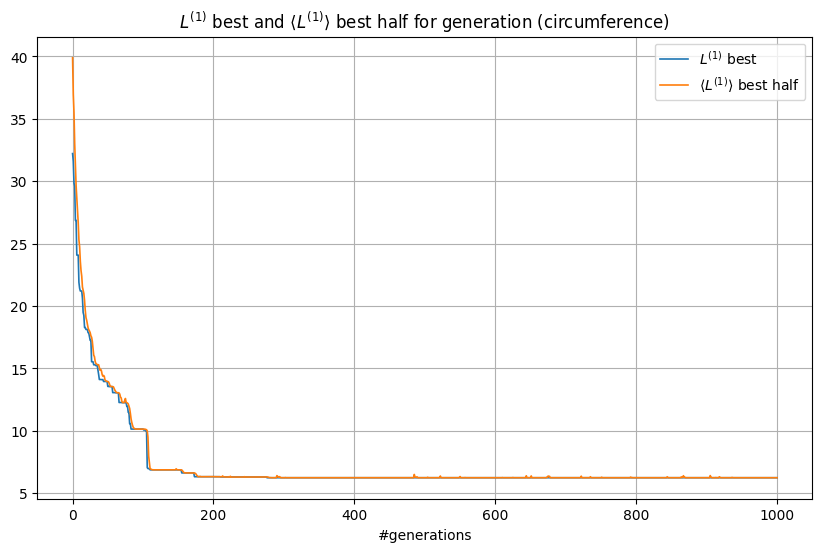

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the evolution of the best path length and the average over the best half of the population
def plot(filename, x_name, title, linewidth):
    plt.figure(figsize=(10, 6))

     # Load the generation index and the length of the best individual
    x, y = np.loadtxt(filename, usecols=(0, 1), unpack=True)
    plt.plot(x, y, "-", linewidth=linewidth, label =r'$L^{(1)}$ best')

    # Load the generation index and the average path length 
    x2, y2 = np.loadtxt(filename, usecols=(0, 2), unpack=True)
    plt.plot(x2, y2, "-", linewidth=linewidth, label =r'$\langle L^{(1)}\rangle$ best half' )

    plt.xlabel(x_name)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Circle

plot("Output/outputL1_best.txt", '#generations', r'$L^{(1)}$ best and $\langle L^{(1)}\rangle$ best half for generation (circumference)', 1.2)

Si osserva che già dopo circa $200$ generazioni viene raggiunto il path ottimale.
Si mostra inoltre anche il path ottimizzato (percorso del primo individuo dell'ultima popolazione ordinata) ed il path peggiore (percorso dell'ultimo individuo della prima popolazione ordinata) nel piano cartesiano.

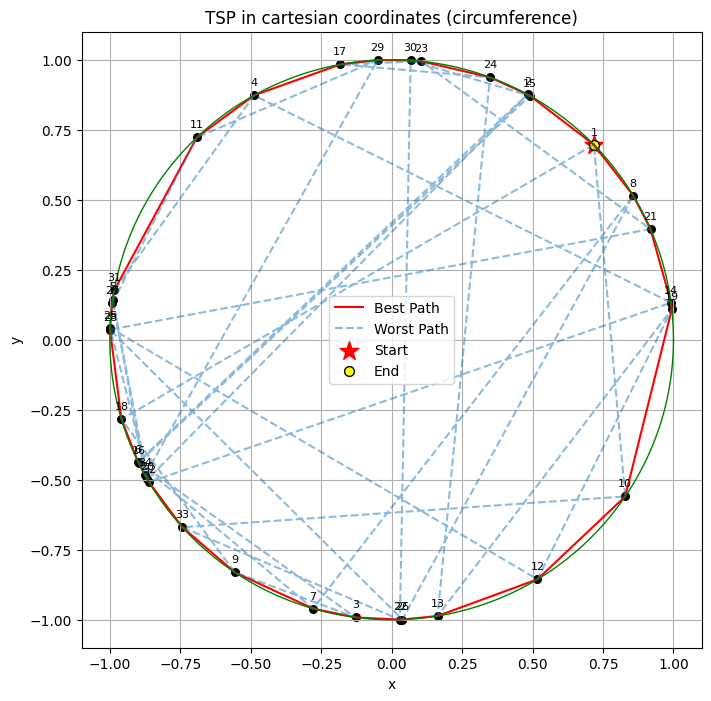

In [4]:
# Plot the best and worst paths in Cartesian coordinates
def plot_path(filename, filename2, x_name, y_name, title, linewidth, circonferenza = False, quadrato = False ):
    plt.figure(figsize=(8, 8))

    # Load coordinates and city indices of the optimized path
    x, y, i = np.loadtxt(filename, usecols=(0, 1, 2), unpack=True)
    plt.plot(x, y, "-", linewidth=linewidth, label =r'Best Path', color = "red")

     # Load the coordinates of the worst path 
    x2, y2 = np.loadtxt(filename2, usecols=(0, 1), unpack=True)
    plt.plot(x2, y2, "--", linewidth=linewidth, label =r'Worst Path', alpha = 0.5)

    # Draw the unit circumference
    if circonferenza == True:
        theta = np.linspace(0, 2*np.pi, 500)
        plt.plot(np.cos(theta), np.sin(theta), "-", linewidth = 1, color = "green")

    # Draw the the unit square
    if quadrato == True: 
        x_square = [0, 1, 1, 0, 0]
        y_square = [0, 0, 1, 1, 0]
        plt.plot(x_square, y_square, "-", linewidth = 1, color = "green")
        plt.axis("equal")

    # Mark all cities and highlight the starting and final cities
    plt.scatter(x, y, s=30, color="black")
    plt.scatter(x[0], y[0], s=200, marker = "*", color="red", label="Start")
    plt.scatter(x[-1], y[-1], s=50, color="yellow", edgecolors="black", label="End")

    i = i.astype(int)
    # Label each city using the index stored in the third column
    for xi, yi, index in zip(x[:-1], y[:-1], i[:-1]):
        plt.annotate(str(index), (xi, yi), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8)

    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Circle

plot_path("Output/BestPath.txt", "Output/WorstPath.txt", "x", "y", "TSP in cartesian coordinates (circumference)", 1.5, circonferenza = True, quadrato = False)

Si mostrano ora gli stessi grafici per il caso di $34$ città disposte all'interno del quadrato:

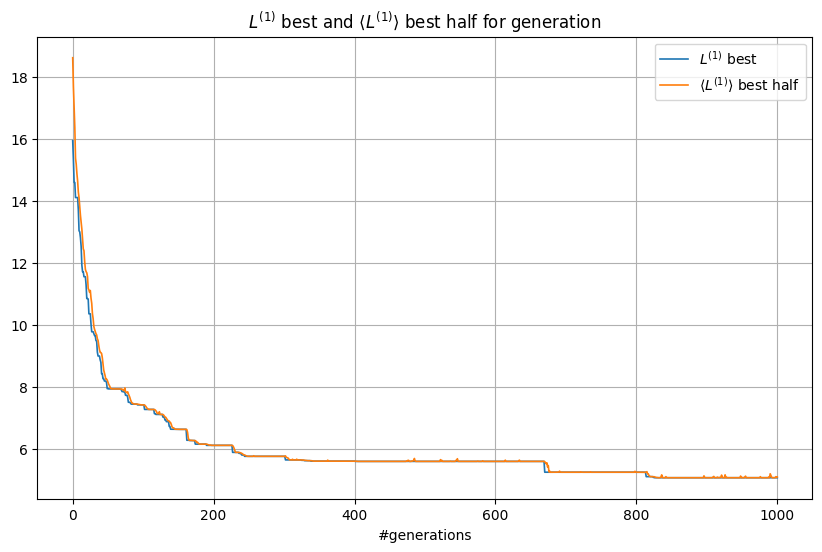

In [5]:
# Square
plot("Output/outputL1_best_square.txt", '#generations', r'$L^{(1)}$ best and $\langle L^{(1)}\rangle$ best half for generation', 1.2)

In questo caso si osserva una convergenza più lenta.

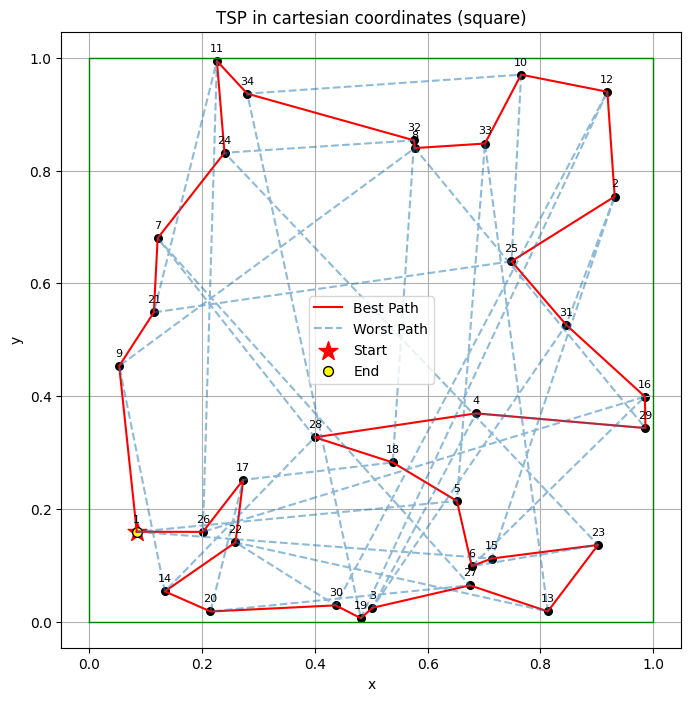

In [7]:
plot_path("Output/BestPath_square.txt", "Output/WorstPath_square.txt", "x", "y", "TSP in cartesian coordinates (square)", 1.5, circonferenza = False, quadrato = True)